In [476]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [477]:
df = sns.load_dataset("titanic")

In [478]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [479]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [480]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [481]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [482]:
df.drop("deck", axis=1, inplace=True)

In [483]:
numerical_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numerical_col

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

In [484]:
categorical_col = df.select_dtypes(include=["object","category"]).columns.tolist()
categorical_col

['sex', 'embarked', 'class', 'who', 'embark_town', 'alive']

In [485]:
from sklearn.impute import SimpleImputer

In [486]:
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

In [487]:
for col in df[numerical_col]:
  df[col+"_imputed"] = num_imputer.fit_transform(df[[col]]).ravel()

In [488]:
for col in df[categorical_col]:
  df[col+"_imputed"] = cat_imputer.fit_transform(df[[col]]).ravel()

In [489]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,age_imputed,sibsp_imputed,parch_imputed,fare_imputed,sex_imputed,embarked_imputed,class_imputed,who_imputed,embark_town_imputed,alive_imputed
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,22.0,1.0,0.0,7.2500,male,S,Third,man,Southampton,no
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,38.0,1.0,0.0,71.2833,female,C,First,woman,Cherbourg,yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,26.0,0.0,0.0,7.9250,female,S,Third,woman,Southampton,yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,35.0,1.0,0.0,53.1000,female,S,First,woman,Southampton,yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,35.0,0.0,0.0,8.0500,male,S,Third,man,Southampton,no


In [490]:
df.drop(numerical_col, axis=1, inplace=True)
df.drop(categorical_col, axis=1, inplace=True)

In [491]:
df.columns

Index(['adult_male', 'alone', 'survived_imputed', 'pclass_imputed',
       'age_imputed', 'sibsp_imputed', 'parch_imputed', 'fare_imputed',
       'sex_imputed', 'embarked_imputed', 'class_imputed', 'who_imputed',
       'embark_town_imputed', 'alive_imputed'],
      dtype='object')

In [492]:
df.isnull().sum()

,0
adult_male,0
alone,0
survived_imputed,0
pclass_imputed,0
age_imputed,0
sibsp_imputed,0
parch_imputed,0
fare_imputed,0
sex_imputed,0
embarked_imputed,0


In [493]:
numerical_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numerical_col

['survived_imputed',
 'pclass_imputed',
 'age_imputed',
 'sibsp_imputed',
 'parch_imputed',
 'fare_imputed']

In [494]:
categorical_col = df.select_dtypes(include=["object","category"]).columns.tolist()
categorical_col

['sex_imputed',
 'embarked_imputed',
 'class_imputed',
 'who_imputed',
 'embark_town_imputed',
 'alive_imputed']

In [495]:
from sklearn.preprocessing import MinMaxScaler

In [496]:
minmax_col  = [col for col in numerical_col if abs(df[col].skew()) >= 0.5]
minmax_col

['pclass_imputed', 'sibsp_imputed', 'parch_imputed', 'fare_imputed']

In [497]:
for col in minmax_col:
  df[col+"_scaled"] = MinMaxScaler().fit_transform(df[[col]]).ravel()

In [498]:
df.drop(minmax_col, axis=1, inplace=True)

In [499]:
numerical_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numerical_col

['survived_imputed',
 'age_imputed',
 'pclass_imputed_scaled',
 'sibsp_imputed_scaled',
 'parch_imputed_scaled',
 'fare_imputed_scaled']

In [500]:
from sklearn.preprocessing import Normalizer

In [501]:
norm = Normalizer()

In [502]:
std_devs = df[numerical_col].std()
normalize_cols = std_devs[std_devs > 1].index.tolist()
normalize_cols

['age_imputed']

In [503]:
for col in normalize_cols:
  df[col+"_normalized"] = norm.fit_transform(df[[col]]).ravel()

In [504]:
numerical_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numerical_col

['survived_imputed',
 'age_imputed',
 'pclass_imputed_scaled',
 'sibsp_imputed_scaled',
 'parch_imputed_scaled',
 'fare_imputed_scaled',
 'age_imputed_normalized']

In [505]:
from sklearn.preprocessing import StandardScaler

In [506]:
scaler = StandardScaler()

In [507]:
standard_col = [col for col in numerical_col if abs(df[col].skew()) < 0.5]
standard_col

['survived_imputed', 'age_imputed', 'age_imputed_normalized']

In [508]:
numerical_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numerical_col

['survived_imputed',
 'age_imputed',
 'pclass_imputed_scaled',
 'sibsp_imputed_scaled',
 'parch_imputed_scaled',
 'fare_imputed_scaled',
 'age_imputed_normalized']

In [509]:
for col in standard_col:
  df[col+"_scaled"] = scaler.fit_transform(df[[col]]).ravel()

In [510]:
df.drop(standard_col, axis=1, inplace=True)

In [511]:
numerical_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numerical_col

['pclass_imputed_scaled',
 'sibsp_imputed_scaled',
 'parch_imputed_scaled',
 'fare_imputed_scaled',
 'survived_imputed_scaled',
 'age_imputed_scaled',
 'age_imputed_normalized_scaled']

In [512]:
df.head()

,adult_male,alone,sex_imputed,embarked_imputed,class_imputed,who_imputed,embark_town_imputed,alive_imputed,pclass_imputed_scaled,sibsp_imputed_scaled,parch_imputed_scaled,fare_imputed_scaled,survived_imputed_scaled,age_imputed_scaled,age_imputed_normalized_scaled
0,True,False,male,S,Third,man,Southampton,no,1.0,0.125,0.0,0.014151,-0.789272,-0.592481,0.0
1,False,False,female,C,First,woman,Cherbourg,yes,0.0,0.125,0.0,0.139136,1.266990,0.638789,0.0
2,False,True,female,S,Third,woman,Southampton,yes,1.0,0.000,0.0,0.015469,1.266990,-0.284663,0.0
3,False,False,female,S,First,woman,Southampton,yes,0.0,0.125,0.0,0.103644,1.266990,0.407926,0.0
4,True,True,male,S,Third,man,Southampton,no,1.0,0.000,0.0,0.015713,-0.789272,0.407926,0.0


In [513]:
df.isnull().sum()

,0
adult_male,0
alone,0
sex_imputed,0
embarked_imputed,0
class_imputed,0
who_imputed,0
embark_town_imputed,0
alive_imputed,0
pclass_imputed_scaled,0
sibsp_imputed_scaled,0


In [514]:
from sklearn.preprocessing import LabelEncoder

In [515]:
le = LabelEncoder()

In [516]:
le_col = [col for col in categorical_col if df[col].nunique() == 2]
le_col

['sex_imputed', 'alive_imputed']

In [517]:
for col in le_col:
  df[col+"_encoded"] = le.fit_transform(df[[col]])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [518]:
df.drop(le_col, axis=1, inplace=True)

In [519]:
categorical_col = df.select_dtypes(include=["object","category"]).columns.tolist()
categorical_col

['embarked_imputed', 'class_imputed', 'who_imputed', 'embark_town_imputed']

In [520]:
from sklearn.preprocessing import OneHotEncoder

In [521]:
oh = OneHotEncoder()

In [522]:
categorical_col = df.select_dtypes(include=["object","category","bool"]).columns.tolist()
oh_col = [col for col in categorical_col if df[col].nunique() > 2]
oh_col

['embarked_imputed', 'class_imputed', 'who_imputed', 'embark_town_imputed']

In [523]:
for col in oh_col:
    encoded = pd.DataFrame(
        OneHotEncoder(sparse_output=False).fit_transform(df[[col]]),
        columns=OneHotEncoder(sparse_output=False).fit(df[[col]]).get_feature_names_out([col]),
        index=df.index
    )
    df = pd.concat([df, encoded], axis=1)

In [524]:
oh_col = ['embarked_imputed', 'class_imputed', 'who_imputed', 'embark_town_imputed']
df.drop(oh_col, axis=1, inplace=True)

In [525]:
df.dtypes

,0
adult_male,bool
alone,bool
pclass_imputed_scaled,float64
sibsp_imputed_scaled,float64
parch_imputed_scaled,float64
fare_imputed_scaled,float64
survived_imputed_scaled,float64
age_imputed_scaled,float64
age_imputed_normalized_scaled,float64
sex_imputed_encoded,int64


In [526]:
from sklearn.feature_selection import SelectKBest, f_classif

In [527]:
y = df["survived_imputed_scaled"]
X = df.drop("survived_imputed_scaled", axis=1)

In [528]:
len(df.columns)

23

In [529]:
selector = SelectKBest(score_func=f_classif, k=15)

In [530]:
X_new = selector.fit_transform(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [7 9] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [531]:
scores = selector.scores_

for feature, score in zip(X.columns, scores):
    print(feature, score)

adult_male 400.0375626747448
alone 38.35365139840699
pclass_imputed_scaled 115.03127218827667
sibsp_imputed_scaled 1.1105722041132329
parch_imputed_scaled 5.9634638366035935
fare_imputed_scaled 63.03076422804432
age_imputed_scaled 4.353516089078487
age_imputed_normalized_scaled nan
sex_imputed_encoded 372.40572360221483
alive_imputed_encoded inf
embarked_imputed_C 25.89598699556588
embarked_imputed_Q 0.011846343990383331
embarked_imputed_S 20.374459882803
class_imputed_First 79.13640330912594
class_imputed_Second 7.814804722804994
class_imputed_Third 103.05759939384174
who_imputed_child 16.779668158665228
who_imputed_man 400.0375626747448
who_imputed_woman 306.8647818583965
embark_town_imputed_Cherbourg 25.89598699556588
embark_town_imputed_Queenstown 0.011846343990383331
embark_town_imputed_Southampton 20.374459882803


In [532]:
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['adult_male', 'alone', 'pclass_imputed_scaled', 'fare_imputed_scaled',
       'sex_imputed_encoded', 'alive_imputed_encoded', 'embarked_imputed_C',
       'embarked_imputed_S', 'class_imputed_First', 'class_imputed_Third',
       'who_imputed_child', 'who_imputed_man', 'who_imputed_woman',
       'embark_town_imputed_Cherbourg', 'embark_town_imputed_Southampton'],
      dtype='object')


In [533]:
X = X[selected_features]

In [534]:
from sklearn.model_selection import train_test_split

In [535]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [536]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [537]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [538]:
y_train_discrete = y_train.apply(lambda x: 0 if x < 0 else 1)
y_test_discrete = y_test.apply(lambda x: 0 if x < 0 else 1)

model.fit(X_train, y_train_discrete)

RandomForestClassifier(random_state=42)

In [539]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test_discrete, y_pred))
print("\nClassification Report:\n", classification_report(y_test_discrete, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



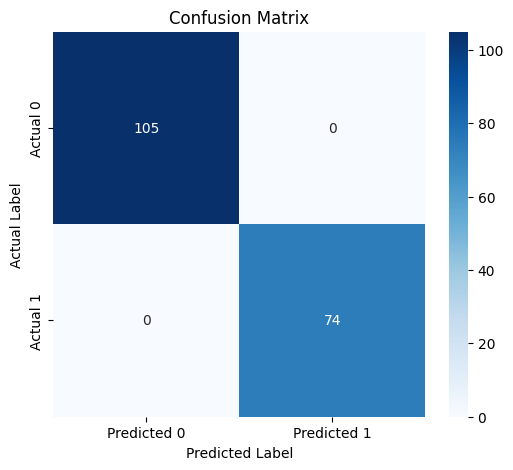

In [540]:
cm = confusion_matrix(y_test_discrete, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()